# El perceptrón

## Las partes del perceptrón
El perceptrón (moderno) cuenta con varias partes.
1) **Inputs**: Las entradas del perceptrón. Normalmente denominadas $X = x_0, x_1, x_1, ..., x_n$, es un vector de números.
2) **Weights**: Los pesos del perceptrón. También llamados parámetros del modelo, estos pesos son los que se aprenden durante el proceso de entrenamiento y los que determinan la salida del modelo. Normalmente se lo denomina $W = W_0, W_1, W_2, ..., W_n$. 
3) **Agregation**: Una función de agregación. En general es una suma. Por eso se dice que el perceptrón implementa una suma ponderada, por que es la suma de las entradas ($X$) multiplicada por los pesos ($W$).
4) **Non-linearity**: Una función no lineal de activación. Es una función que determina si el perceptrón se activa o no dada una entrada. Por este motivo se la conoce como `función de activación`. Esta función es no lineal (al contrario de la suma ponderada) y generalmente es una de las siguientes: https://ml-explained.com/blog/activation-functions-explained
5) **Output**: La salida del perceptrón. Normalmente denominada $\hat{y}$ (se pronuncia "y sombrero" o "y hat"), es un valor numérico que luego será interpretado en el contexto del modelo. Volviendo al ejemplo de los gatitos, si la salida es 0 se puede interpretar como que NO hay gatos en la imagen y 1 como lo que SI hay gatos en la imagen.

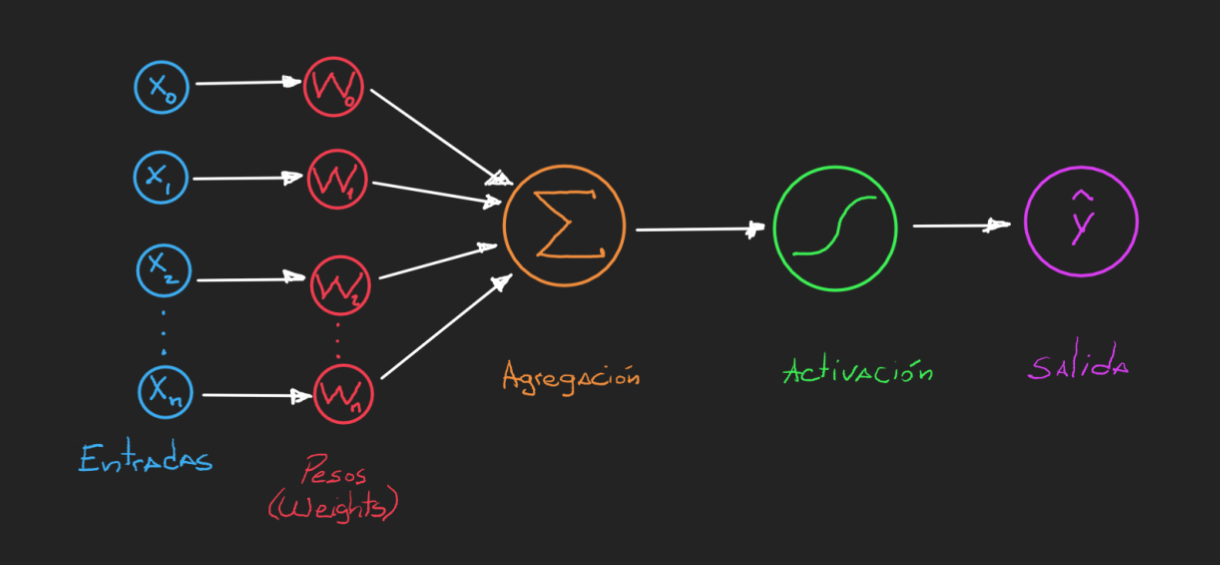

## Que significa entrenar un perceptrón?
Veamos un ejemplo más de como se entrena un perceptrón. Dijimos que para entender cómo se entrena un perceptrón nos conviene ver a éste como una fórmula matemática, donde la salida $\hat{y}$ es el resultado de aplicar alguna función a las entradas $X$. Si llamamos a esta función $f$, entonces, $\hat{y}$ no es otra cosa que $$\hat{y} = f(X)$$

Noten que los pesos $W$ no son parámetros de entrada de la función, pero estos operan con los $X$ multiplicativamente. Además, la función de activación también afecta la salida. Podemos escribir la $f$ de la siguiente manera:
$$f(X) = act(x_0W_0+x_1W_1+...+x_nW_n)$$
Podemos hacer el ejercicio de determinar cuántas funciones de estas existen y nos daríamos cuenta rápidamente que son infinitas. Para cada combinación de valores de $W$ tendremos que la función $f$ se comporta distinto para la misma entrada $X$. Por ejemplo, para las $f$'s de dos entradas:

$$f_1(x_0,x_1) = ReLU(x_02 + x_14)$$
$$f_2(x_0,x_1) = ReLU(x_00.5 + x_10.3)$$
$$f_3(x_0,x_1) = tanh(x_02 + x_14)$$
Cada una de estas funciones retorna un $\hat{y}$ diferente dada la misma entrada $X$.

Esta salida ($\hat{y}$) es la predicción del modelo y cada $f$ será un modelo distinto. Entrenar un perceptrón es encontrar una asignación de valores para los pesos $W$ que haga que las predicciones del modelo "que sean buenas" en el contexto del problema que quiero resolver. Si el perceptrón está sin entrenar, la salida del modelo es cualquier cosa. Pero cuando el perceptrón está entrenado, dada una entrada $X$, el modelo va a realizar una predicción $\hat{y}$ para esa entrada. Que tan buena es la predicción se mide usando la función de perdida o *loss function*.

Pongamos todo esto en práctica. Definamos un problema y busquemos una solución usando un perceptrón.

### La puerta lógica OR
Supongamos que queremos entrenar una función $f$ que tiene como entrada un único $X = [x_0, x_1]$ de manera tal que $f$ se comporte como el OR lógico. Recordemos que el OR acepta entradas binarias, 0 o 1, y que cuando tanto $x_0$ como $x_1$ son 0, el resultado $y$ será 0 y será 1 en caso contrario. La tabla completa del OR es como sigue:

|  x₀ |  x₁ |   x₀ OR x₁ |
|-----|-----|------------|
|  0  |  0  |      0     |
|  0  |  1  |      1     |
|  1  |  0  |      1     |
|  1  |  1  |      1     |

Sabiendo esto podemos usar los $X = [x_0, x_1]$ como entradas y el resultado de la operación OR como las etiquetas para entrenar un perceptrón. Es decir que nuestro $X$ será $X = [[0, 0], [0, 1], [1, 0], [1, 1]]$ y nuestro $y$ será $y = [0, 1, 1, 1]$. Vamos a usar **Michigrad** para representar los valores de nuestro perceptrón para poder hacer backpropagation y para visualizar el grafo de operaciones y los gradientes .

In [1]:
#imports matplotlib, numpy, michigrad
from michigrad.engine import Value
from michigrad.visualize import show_graph
import matplotlib.pyplot as plt
import numpy as np

In [2]:
x00 = Value(0., name='x0=0')
x01 = Value(1., name='x0=1')
x10 = Value(1., name='x1=0')
x11 = Value(1., name='x1=1')

y0 = Value(0., name='y=0')
y1 = Value(1., name='y=1')

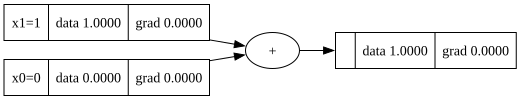

In [3]:
show_graph(x00 + x11)

## Definiendo un perceptrón para implementar una computar OR
Definamos entonces nuestro perceptrón como una función $f$ de la siguiente manera. $$\hat{y} = f(X) = σ(x_0 * W_0 + x_1 * W_1 + b)$$


Hay varias cosas nuevas. Por una lado, el término $b$ se conoce como *bias*. Es un peso independiente de los $W$ y de las entradas, pero es equivalente a:
$$\hat{y} = f(X) = σ(x_0 * W_0 + x_1 * W_1 + 1 * W_2)$$
Así que está bien asociar $b$ con un peso $W_2$, un peso nuevo que hace falta entrenar en el perceptrón. Pero es un peso libre que no se relaciona multiplicativamente con ninguna de las entradas.

Lo otro nuevo es que ahora el perceptrón usa una función de activación $σ$ llamada *sigmoide*. Esta función que retorna valores entre 0 y 1 y tiene forma de letra S. No es la única función que tiene esta forma, por ello hablando estrictamente, usaremos la función logística que se define así:
$$σ(x) = \frac{1}{1+e^{-x}}$$
En general, cuando hablemos de función sigmoide en Machine Learning, esteremos hablando de la función logística.

In [4]:
# definir la función sigmoid(x)
def sigmoid(x: Value): 
    return 1 / (1 + (-x).exp())


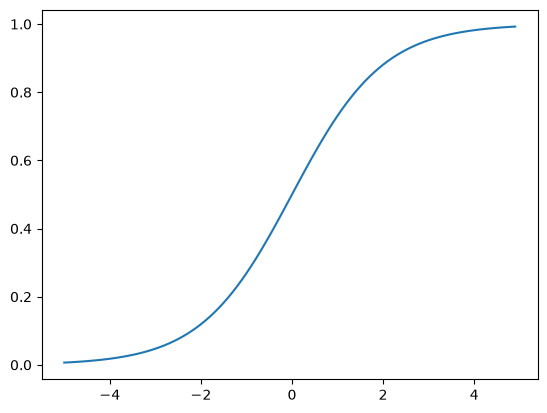

In [5]:
# mostrar el grafico de la función
x = np.arange(-5, 5, 0.1) # De 5 a 5 avanzado a 0,1 pasos
s = []
for i in x:
    s.append(sigmoid(Value(i)).data) #Data lo usamos para plotearlo
    
plt.plot(x, s)

In [6]:
# mostrar la invocación sigmoid
sigmoid(Value(1))

Value(data=0.7310585786300049, grad=0, name=)

Definamos ahora los pesos de nuestro perceptrón, no conviene inicializarlos en random ya que podria haber numeros muy grandes y tardar mucho. La idea es tener la menor cantidad de ciclos (Despues lo vamos a ver). Hay una forma sensata de hacerlo con la idea de que tengan una distribucion normal aunque a veces puede variar

In [7]:
np.random.seed(42)
w0 = Value(np.random.random(), name='w0')
w1 = Value(np.random.random(), name='w1')
b = Value(np.random.random(), name='bias')


Dado nuestro perceptrón escrito así $\hat{y} = f(X) = σ(x_0 * W_0 + x_1 * W_1 + b)$, y con la función `sigmoid(x)` y los pesos $W$ definidos, estamos listos para probar nuestro perceptrón!

In [8]:
# hacer una forward pass
sigmoid(x00*w0 + x11*w1 + b)

Value(data=0.8432628148712872, grad=0, name=)

In [9]:
# declarar los yhat
yhat00 = sigmoid(x00*w0 + x10*w1 + b)
yhat01 = sigmoid(x00*w0 + x11*w1 + b)
yhat10 = sigmoid(x01*w0 + x10*w1 + b)
yhat11 = sigmoid(x11*w0 + x11*w1 + b)

print(yhat00, yhat01, yhat10, yhat11)

Value(data=0.8432628148712872, grad=0, name=) Value(data=0.8432628148712872, grad=0, name=) Value(data=0.8866779795050286, grad=0, name=) Value(data=0.8866779795050286, grad=0, name=)


El resultado no está ni cerca de el valor esperado para nuestra función $f$. Por ejemplo, para $x_0 = 0$ y $x_1 = 0$ el resultadado debería ser $1$ (porque *OR*$(0,1) = 1$). Vimos que esto se llama *Forward Pass*. Enviamos la entrada a la función, la ejectuamos y vemos cual es el resultado. Lo que intuitivamente deberíamos hacer ahora es modificar los pesos $W$ para que la próxima vez que ejecutemos la función $f$, el resultado se acerque más al valor esperado. Para esto, debemos calcular cuan lejos está el resultado del modelo $\hat{y}$ (la predicción) del verdadero valor (esperado) para la función $f$ al cual llamamos $y$. La forma de calcular la distancia entre $\hat{y}$ e $y$ depende del problema y puede ser todo lo complicada que uno quiera. Está claro que es otra función que depende de los valores esperados (lo que queremos que el modelo devuelva, $y$) y los valores predichos (lo que el modelo devuelve de verdad. $\hat{y}$), y que estos valores además dependen de las entradas $X$ y de los pesos $W$. Esta nueva función se llama *función de pérdida* o *loss function* y en las fórmulas la vamos a llamar $L$.  

Para muchos muchos problemas, alcanza con que $L$ sea la diferencia (la resta) entre el valor esperado y el valor predicho. Eso de alguna manera nos dará información de la distancia a la que estamos del valor esperado dada una predicción. Existen varios problemas con este enfoque. El primero es que la resta tiene signo (puede dar valores negativos). Ya veremos por que esto es un problema. Lo segundo es que idealmente queremos que el valor de $L$ represente de alguna manera que tan lejos estamos del objetivo, no solo para un caso de las entradas sino para todos los valores que puedan tomar las entradas $X$ (o al menos para unos cuantos).

Para eliminar estos problemas, en lugar de la resta, utilizamos el error cuadrático medio (MSE). El MSE se puede definir formalmente, usando la misma notación que venimos usando, como:
$$MSE(y,\hat{y}) = \frac{1}{n} \sum_i^n (y_i - \hat{y}_i)²$$

De esa manera, podemos representar que tan lejos estamos del objetivo usando una función que retorna un único valor positivo para la distancia entre un grupo de entradas y un grupo de salidas. Escribamos todo esto en python.

In [10]:
# declarar L
L = ((y0-yhat00)**2 + (y1-yhat01)**2 + (y1-yhat10)**2 + (y1 - yhat11)**2)/4
L.name = 'L'

Intuitivamente, podemos ver que $L$ valdrá 0 solamente cuando los valores predichos $\hat{y}$ sean iguales a $y$. "Entrenar" un perceptrón o una red neuronal para que aprenda algo, es matemáticamente equivalente a ajustar los pesos $W$ de manera tal de minimizar la función de perdida $L$.

Esto puede hacerse a mano, pero incluso para este caso simple de un único perceptrón con dos entradas y tres pesos, con una función de pérdida bastante simple, el grafo de operaciones de $L$ es bastante grande.

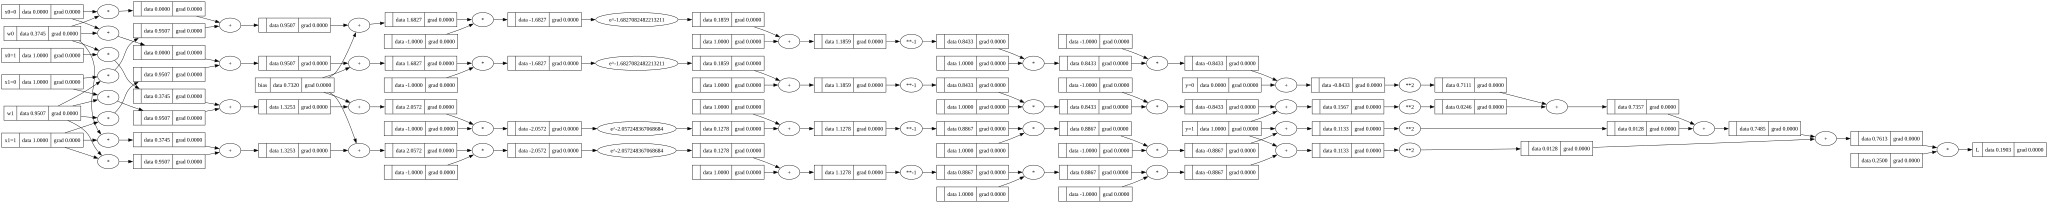

In [11]:
# mostrar el grafo de L
show_graph(L)

Por lo general, para entrenar los pesos, buscamos los gradientes utilizando un motor de cálculo de gradientes. Nosotros estamos utilizando *Value*'s de Michigrad y estos values guardan información del gradiente y de las operaciones que dan lugar a cada nodo. Esto da la posibilidad de calcular automaticamente los gradientes de todos los nodos de grafo de operaciones de $L$. Esto se logra ejecutando la función `backward()` sobre el último nodo del grafo, es decir $L$.

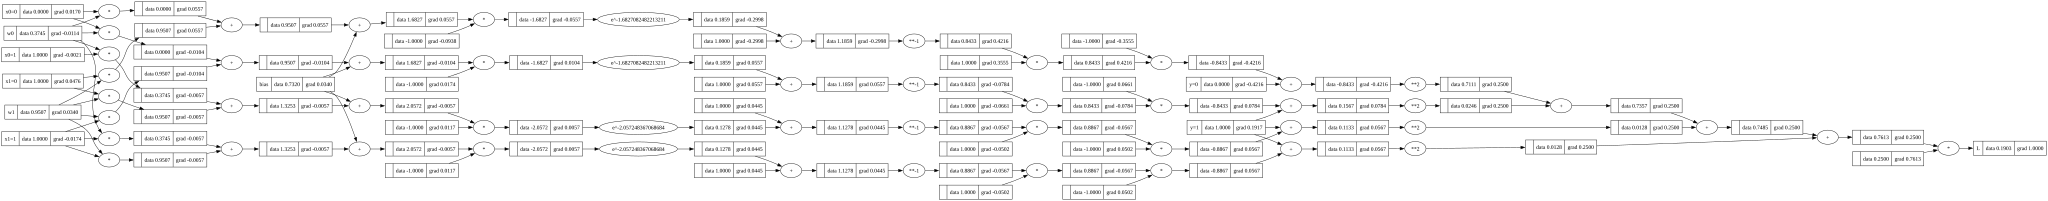

In [12]:
L.backward()
show_graph(L)

Me importan los gradientes de los pesos y del bias ya que esos me modifican el L

Al tener los valores calculados con Michigrad, es posible a su vez calcular como cada uno de los dos $W$, $W_0$, $W_1$ y $b$ afectan a $L$. Luego haremos cosas parecidas usando un motor más potente, **PyTorch**. Sin embargo, lo vamos a hacer por una cuestión de eficiencia. Tanto Michigrad, como [Micrograd](https://github.com/karpathy/micrograd) (el motor de Andrej Karpathy en el que basamos Michigrad), como [PyTorch](https://pytorch.org/), como [TensorFlow](https://www.tensorflow.org/) y otros motores de cálculo de gradientes usan esencialmente las mismas matemáticas, basadas en las derivadas parciales y la aplicación de la regla de la cadena usando programación dinámica.

Durante el curso, implementaremos Michigrad para desmistificar este paso que ahora parece magia. La función `backward()` que Michigrad provee permite determinar que sucede con $L$ ante una modificación en alguno de los $W$. Por ejemplo, si el gradiente de $W_0$ es positivo, sumarle algo a `W_0.data` hará que L aumente. Si por el contrario el gradiente es negativo, sumarle algo a `W_0.data` hará que $L$ disminuya.

In [13]:
# mostrar L, W
print(f'L: {L}')
print(f'w0: {w0}')


L: Value(data=0.19033562020121114, grad=1, name=L)
w0: Value(data=0.3745401188473625, grad=-0.011386612503218697, name=w0)


In [14]:
# modificar W
w0.data -= 0.6

In [15]:
w0

Value(data=-0.2254598811526375, grad=-0.011386612503218697, name=w0)

In [19]:
# calcular yhat y L
yhat00 = sigmoid(x00*w0 + x10*w1 + b)
yhat01 = sigmoid(x00*w0 + x11*w1 + b)
yhat10 = sigmoid(x01*w0 + x10*w1 + b)
yhat11 = sigmoid(x11*w0 + x11*w1 + b)
L = ((y0-yhat00)**2 + (y1-yhat01)**2 + (y1-yhat10)**2 + (y1 - yhat11)**2)/4
L.name = 'L'
L

Value(data=0.1869071956912315, grad=0, name=L)

Lo que debemos hacer ahora es escribir un bucle de entrenamiento para nuestro perceptrón. Recordemos los pasos que debe tener el bucle
1. Hacer la *forward pass*, para ver cual es el resultado del model para $\hat{y}$ para todas las entradas en nuestro conjunto de entrenamiento.
2. Calcular la función de perdida $L$ en base a los valores conocidos de $y$ y los recientemente calculados para $\hat{y}$.
3. Poner los gradientes para los pesos $W$ en cero.
4. Ejecturar el algoritmo de backpropagation para calcular los gradientes de los pesos $W$.
5. Actualizar los pesos de $W$ en la dirección contraria al gradiente.

In [33]:
# escribir el training loop
for i in range(10000):
    # Forward pass
    yhat00 = sigmoid(x00*w0 + x10*w1 + b)
    yhat00.name = 'y00'
    yhat01 = sigmoid(x00*w0 + x11*w1 + b)
    yhat01.name = 'y01'
    yhat10 = sigmoid(x01*w0 + x10*w1 + b)
    yhat10.name = 'y10'
    yhat11 = sigmoid(x11*w0 + x11*w1 + b) # Forward pass -> Ejecutar el modelo
    yhat11.name = 'y11'
    # Lost Function
    L = ((y0-yhat00)**2 + (y1-yhat01)**2 + (y1-yhat10)**2 + (y1 - yhat11)**2)/4 # Calcular la funcion de perdida
    L.name = 'L'
    # Zero Grad
    w0.grad = 0 # Poner todos los gradiente de la corrida en 0
    w1.grad = 0
    b.grad = 0
    # Backpropagation
    L.backward() # Aplicar el algoritmo de backpropagation en el grafo de operaciones
    # Realizar el update. Es decir, movernos en la direccion contraria al gradiente
    # el cual se suele multiplicar por un valor muy chiquito. Esto ultimo se llama learning rate que seria que tan brusco es el cambio de W
    w0.data -= w0.grad * 0.1
    w1.data -= w1.grad * 0.1
    b.data -= b.grad * 0.1
    print(L.data)

0.13297635944508804
0.13296239767427434
0.13294847520623473
0.13293459189815826
0.13292074760784078
0.13290694219368251
0.13289317551468488
0.1328794474304479
0.13286575780116755
0.13285210648763268
0.13283849335122244
0.1328249182539037
0.13281138105822798
0.13279788162732895
0.13278441982491987
0.1327709955152906
0.13275760856330518
0.1327442588343989
0.13273094619457604
0.13271767051040687
0.1327044316490252
0.1326912294781257
0.13267806386596154
0.1326649346813414
0.13265184179362727
0.13263878507273158
0.1326257643891149
0.13261277961378332
0.13259983061828587
0.13258691727471203
0.13257403945568938
0.1325611970343808
0.13254838988448234
0.13253561788022045
0.13252288089634975
0.13251017880815052
0.13249751149142625
0.1324848788225011
0.1324722806782178
0.13245971693593497
0.1324471874735249
0.13243469216937107
0.13242223090236582
0.13240980355190812
0.132397409997901
0.13238505012074944
0.13237272380135784
0.132360430921128
0.13234817136195662
0.13233594500623297
0.13232375173683

Probemos el resultado de nuestro modelo entrenado.

In [34]:
sigmoid(1 * w0 + 0*w1 + b)

Value(data=0.9738279944451217, grad=0, name=)

## Resumen

Entrenar un perceptrón, o una red neuronal, los pasos serán siempre los mismos, ya sea usando *Michigrad* o *PyTorch*.

1. Hacer la forward pass. Calcular el valor de nuestra predicción $\hat{y}$ ejecutando el modelo.
2. Calcular la funcion de perdida $L$ en base a los valores conocidos de $y$ (por eso es supervisado). 
3. Poner los gradientes del grafo de dependencias en cero.
4. Ejecutar el algoritmo de backpropagation sobre el grafo de operaciones de $L$ para obtener los gradientes de $W$ respecto de $L$.
5. Actualizar los pesos de los $W$ en la dirección contraria al gradiente.

## Práctica
* Entrenar un perceptrón para que se comporte como una compuerta lógica AND (Dificultad: **Fácil**)
  * Pista: cambiar $y$ para que las etiquetas correspondan con la salida de la compuerta AND.
* Entrenar un perceptrón para que aprenda a sumar $x_0 + x_1$ (Dificultad: **Fácil**)
  * Pista: cambiar $y$ para que las etiquetas corresponda con la suma de $x_0 + x_1$. Reemplazar la función de activación por una ReLU y eliminar el bias.
* Entrenar una perceptrón para que se comporte como una compuerta NAND (Dificultad: **Intermedio**)
  * Pista: reemplazar la función de activación por una $tanh$. Se puede modificar Michigrad (pero hay que implementar backward para la operación) o escribir $tanh(x)$ como $$tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$ Todas esas operaciones se pueden hacer usando los Values de Michigrad.
* Entrenar un perceptrón para que se comporte como una compuerta lógica XOR (Dificultad: **Difícil**)
  * Pista: en este caso no alcanza con usar un perceptrón. Hay que usar varios!